# Stage 4 — Classical Baseline

## Random Forest and Logistic Regression

We train classical ML models on handcrafted acoustic features from `03_eda_acoustic_features.ipynb`, compare performance, and analyse feature importance. This serves as a baseline for the deep learning models (Stage 5+).

**Requires:** `acoustic_features.csv` (from `extract_features.py`).

## 1. Setup

In [11]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path("..")
sys.path.insert(0, str(PROJECT_ROOT))

from config import FEATURES_DIR, OUTPUTS_DIR, RANDOM_SEED, TEST_SIZE, VAL_SIZE
from src.models.baseline import get_feature_importance, make_lr_pipeline, make_rf_pipeline
from src.utils.eval import evaluate_binary

## 2. Load Data and Split

**Important:** We use a **speaker-disjoint** split so that no speaker/source appears in both train and test. A random split inflates AUC (~0.96) because the model can memorize speaker-specific patterns; speaker-disjoint evaluation gives realistic performance (~0.79 AUC).

In [12]:
import numpy as np

df = pd.read_csv(FEATURES_DIR / "acoustic_features.csv")

# Extract speaker/source ID from path (e.g. 8555_xxx -> 8555, 1995_35 -> 1995)
def get_speaker(path):
    return str(Path(path).stem).split("_")[0].split("-")[0]

df["_speaker"] = df["path"].apply(get_speaker)
speakers = np.array(df["_speaker"].unique())
rng = np.random.default_rng(RANDOM_SEED)
rng.shuffle(speakers)
n_test_speakers = max(1, int(len(speakers) * TEST_SIZE))
test_speakers = set(speakers[:n_test_speakers])
train_speakers = set(speakers[n_test_speakers:])

train_df = df[df["_speaker"].isin(train_speakers)].copy()
test_df = df[df["_speaker"].isin(test_speakers)].copy()

# Train/val split within train speakers
val_ratio = VAL_SIZE / (1 - TEST_SIZE)
tr_df, val_df = train_test_split(train_df, test_size=val_ratio, stratify=train_df["label"], random_state=RANDOM_SEED)

# Imputation: use TRAIN median only (no leakage from test)
X_tr_raw = tr_df.drop(columns=["path", "label", "_speaker"])
train_median = X_tr_raw.median(numeric_only=True)

X_tr = X_tr_raw.fillna(train_median)
y_tr = tr_df["label"]
X_val = val_df.drop(columns=["path", "label", "_speaker"]).fillna(train_median)
y_val = val_df["label"]
X_te = test_df.drop(columns=["path", "label", "_speaker"]).fillna(train_median)
y_te = test_df["label"]
feature_names = list(X_tr.columns)

In [13]:
print(f"Train: {len(X_tr)}, Val: {len(X_val)}, Test: {len(X_te)}")
print(f"Speakers — Train: {len(train_speakers)}, Test: {len(test_speakers)} (disjoint)")

Train: 2658, Val: 380, Test: 1273
Speakers — Train: 283, Test: 70 (disjoint)


In [14]:
# Random Forest
rf = make_rf_pipeline(random_state=RANDOM_SEED)
rf.fit(X_tr, y_tr)
rf_metrics = evaluate_binary(y_te.values, rf.predict(X_te), rf.predict_proba(X_te)[:, 1])
print("Random Forest:", rf_metrics)

Random Forest: {'accuracy': 0.5184603299293009, 'precision': 0.7575757575757576, 'recall': 0.38968824940047964, 'f1': 0.5146476642913698, 'confusion_matrix': [[335, 104], [509, 325]], 'auc_roc': 0.6466899373439744}


In [15]:
# Logistic Regression
lr = make_lr_pipeline(random_state=RANDOM_SEED)
lr.fit(X_tr, y_tr)
lr_metrics = evaluate_binary(y_te.values, lr.predict(X_te), lr.predict_proba(X_te)[:, 1])
print("Logistic Regression:", lr_metrics)

Logistic Regression: {'accuracy': 0.5813040062843676, 'precision': 0.8028169014084507, 'recall': 0.4784172661870504, 'f1': 0.599549211119459, 'confusion_matrix': [[341, 98], [435, 399]], 'auc_roc': 0.6862637452680225}


## 3. Train Models

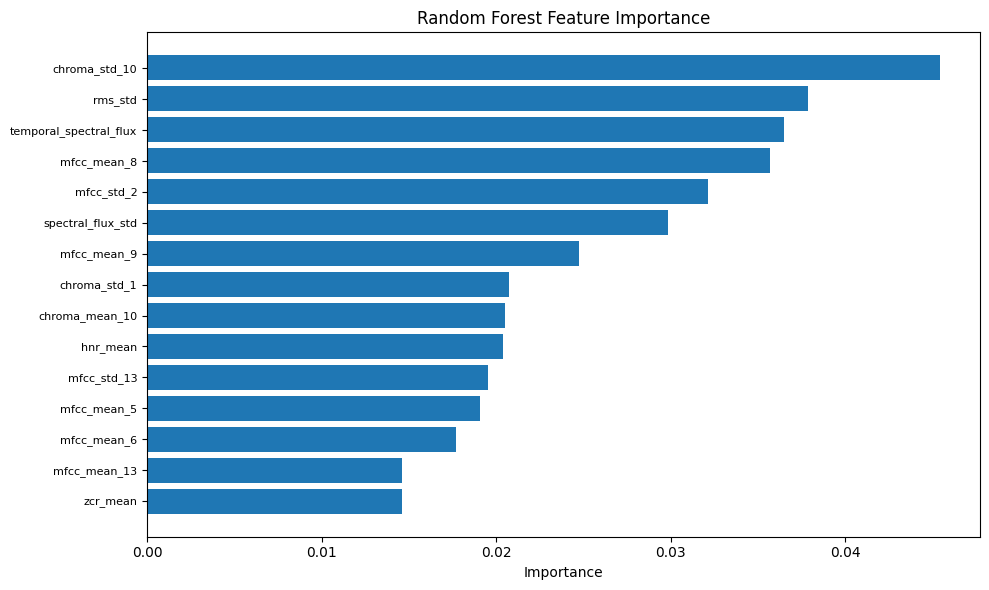

In [16]:
rf_imp = get_feature_importance(rf, feature_names)
top = sorted(rf_imp.items(), key=lambda x: -x[1])[:15]
plt.figure(figsize=(10, 6))
plt.barh(range(len(top)), [t[1] for t in top])
plt.yticks(range(len(top)), [t[0] for t in top], fontsize=8)
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Summary and Limitations

**Summary:** With speaker-disjoint evaluation, metrics are lower than a random split would show (~96% AUC). The random split inflates results because the same speaker/source can appear in both train and test; disjoint splits give realistic generalization estimates.

**Limitations:**
- No temporal modelling: each clip is summarised as a single feature vector.
- Handcrafted feature dependency: performance bounded by acoustic feature design.
- Cannot capture complex time-frequency patterns that deep models might learn.

**Next:** Stage 5 — CNN spectrogram model.

## 4. Results Comparison

Test-set metrics (speaker-disjoint). Lower than a random split would show; this reflects true generalization to unseen speakers/sources.

In [17]:
comparison = pd.DataFrame({
    "Random Forest": [rf_metrics["accuracy"], rf_metrics["precision"], rf_metrics["recall"], rf_metrics["f1"], rf_metrics["auc_roc"]],
    "Logistic Regression": [lr_metrics["accuracy"], lr_metrics["precision"], lr_metrics["recall"], lr_metrics["f1"], lr_metrics["auc_roc"]],
}, index=["Accuracy", "Precision", "Recall", "F1", "AUC-ROC"])
comparison.round(4)

,Random Forest,Logistic Regression
Accuracy,0.5185,0.5813
Precision,0.7576,0.8028
Recall,0.3897,0.4784
F1,0.5146,0.5995
AUC-ROC,0.6467,0.6863


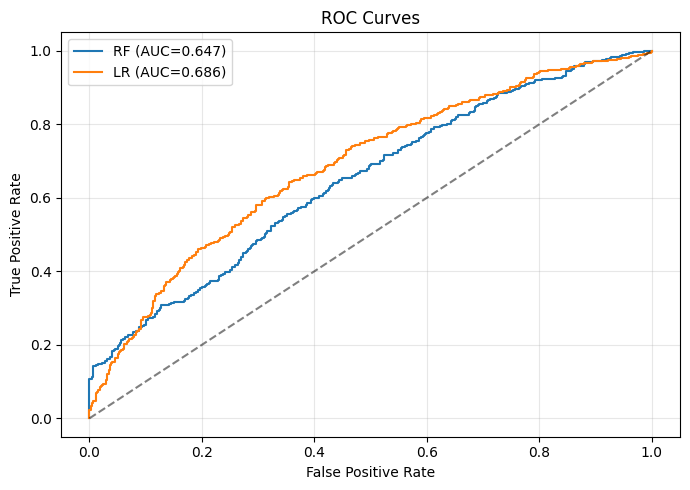

In [18]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(7, 5))
for name, pipe, metrics in [("RF", rf, rf_metrics), ("LR", lr, lr_metrics)]:
    probs = pipe.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, probs)
    ax.plot(fpr, tpr, label=f"{name} (AUC={metrics['auc_roc']:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Feature Importance

RF uses Gini importance; LR uses absolute coefficients. Both highlight which acoustic features drive discrimination.

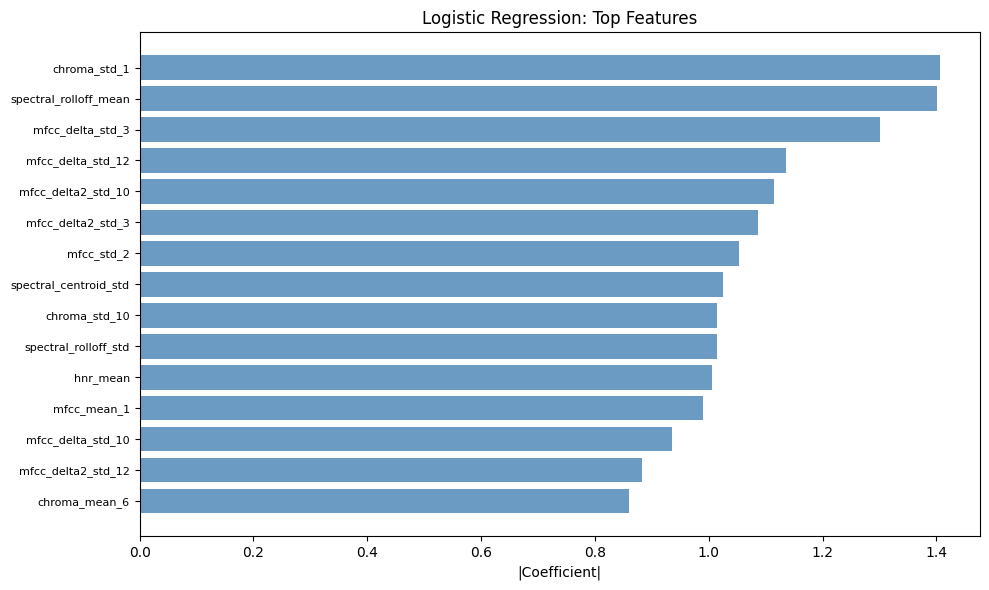

In [19]:
# Logistic Regression: top coefficients (absolute value)
lr_imp = get_feature_importance(lr, feature_names)
top_lr = sorted(lr_imp.items(), key=lambda x: -x[1])[:15]
plt.figure(figsize=(10, 6))
plt.barh(range(len(top_lr)), [t[1] for t in top_lr], color="steelblue", alpha=0.8)
plt.yticks(range(len(top_lr)), [t[0] for t in top_lr], fontsize=8)
plt.xlabel("|Coefficient|")
plt.title("Logistic Regression: Top Features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Save Models

Save trained pipelines for reuse or comparison with later stages.

In [20]:
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(rf, OUTPUTS_DIR / "rf_baseline.joblib")
joblib.dump(lr, OUTPUTS_DIR / "lr_baseline.joblib")
print(f"Saved to {OUTPUTS_DIR}")

Saved to /Users/hadarliav/audio_fraud_detection/outputs
